In [1]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

In [2]:
# Load our data set
x_train = np.array([1.0, 2.0]) #features
y_train = np.array([300.0, 500.0]) #target value

In [3]:
#Function to calculate the cost

def compute_cost(x, y, w, b):

    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i]) **2
    total_cost = 1 / (2 * m) * cost

    return total_cost
    

In [5]:
#Compute Gradients for Linear Regression
def compute_gradient(x, y, w, b):

    # Number of training examples
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
        dj_dw = dj_dw_i
    dj_dw = dj_dw / m
    dj_dwb = dj_db / m

    return dj_dw, dj_db
    

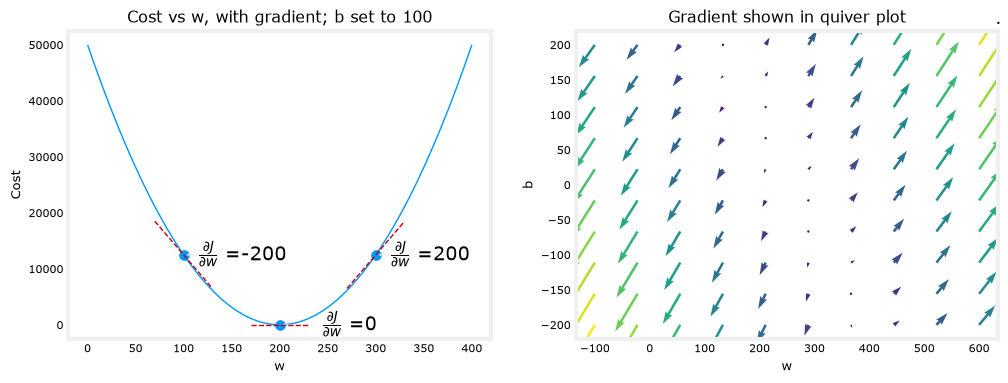

In [7]:
plt_gradients(x_train, y_train, compute_cost, compute_gradient)
plt.show()

In [9]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    #Performs gradient descent to fit w,b. Updates w,b by taking num_iters
    # gradient steps with learning rate alpha.

    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        # Calculate the gradient and update the parameters using gradient_function
        dj_dw, dj_db = gradient_function(x, y, w, b)

        # Update Parameters using equation (3) above
        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        # Save cost J at each iteration
        if i < 100000:     #prevent resource exhaustion
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w,b])

        # Print cost at every interval 10 times or as many iterations if < 10
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e} ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
    return w, b, J_history, p_history #return w and J,w history for graph plotting

In [10]:
# Initialize parameters
w_init = 0
b_init = 0

# Some gradient descent settings
iterations = 10000
tmp_alpha = 1.0e-2

# Run Gradient Descent:
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha,
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 7.87e+04  dj_dw: -5.000e+02, dj_db: -8.000e+02  w:  5.000e+00, b: 8.00000e+00
Iteration 1000: Cost 3.57e+00  dj_dw: -1.303e+00, dj_db:  2.256e+00  w:  1.952e+02, b: 1.08399e+02
Iteration 2000: Cost 1.67e-02  dj_dw: -8.905e-02, dj_db:  1.542e-01  w:  1.997e+02, b: 1.00574e+02
Iteration 3000: Cost 7.80e-05  dj_dw: -6.087e-03, dj_db:  1.054e-02  w:  2.000e+02, b: 1.00039e+02
Iteration 4000: Cost 3.64e-07  dj_dw: -4.160e-04, dj_db:  7.206e-04  w:  2.000e+02, b: 1.00003e+02
Iteration 5000: Cost 1.70e-09  dj_dw: -2.844e-05, dj_db:  4.925e-05  w:  2.000e+02, b: 1.00000e+02
Iteration 6000: Cost 7.95e-12  dj_dw: -1.944e-06, dj_db:  3.367e-06  w:  2.000e+02, b: 1.00000e+02
Iteration 7000: Cost 3.71e-14  dj_dw: -1.329e-07, dj_db:  2.301e-07  w:  2.000e+02, b: 1.00000e+02
Iteration 8000: Cost 1.74e-16  dj_dw: -9.081e-09, dj_db:  1.573e-08  w:  2.000e+02, b: 1.00000e+02
Iteration 9000: Cost 8.11e-19  dj_dw: -6.206e-10, dj_db:  1.075e-09  w:  2.000e+02, b: 1.00000e+02
(w,b) foun

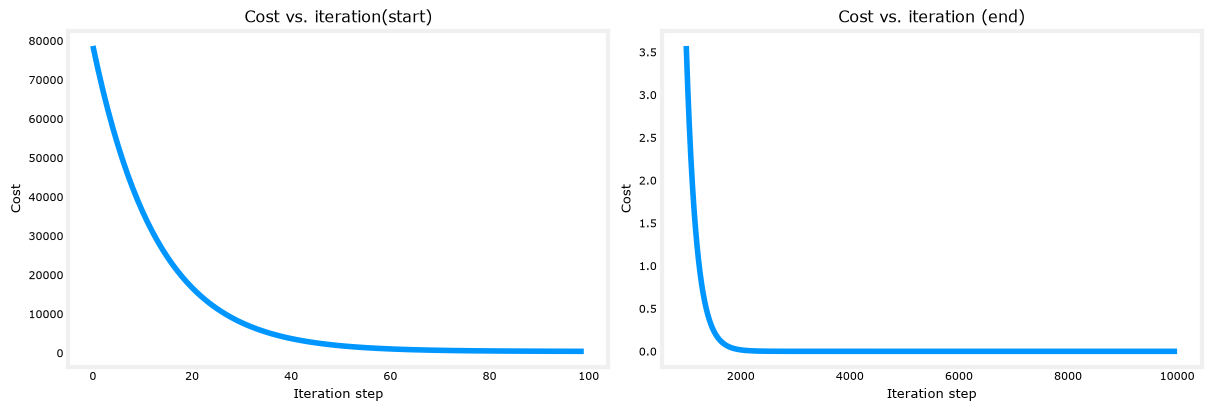

In [11]:
# Plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)"); ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel("Cost"); ax2.set_ylabel("Cost")
ax1.set_xlabel("Iteration step"); ax2.set_xlabel("Iteration step")
plt.show()

In [12]:
# Predictions
print(f"1000 sft house prediction {w_final*1.0 + b_final:0.1f} Thousand dollars")
print(f"1200 sft house prediction {w_final*1.2 + b_final:0.1f} Thousand dollars")
print(f"2000 sft house prediction {w_final*2.0 + b_final:0.1f} Thousand dollars")

1000 sft house prediction 300.0 Thousand dollars
1200 sft house prediction 340.0 Thousand dollars
2000 sft house prediction 500.0 Thousand dollars


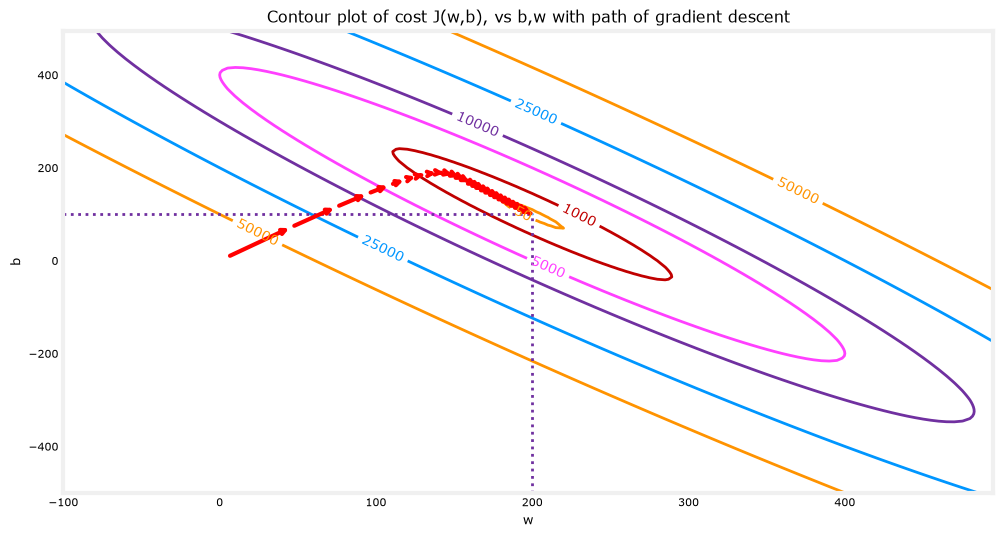

In [13]:

# Contour Plotting
fig, ax = plt.subplots(1,1, figsize=(12,6))
plt_contour_wgrad(x_train, y_train, p_hist, ax)

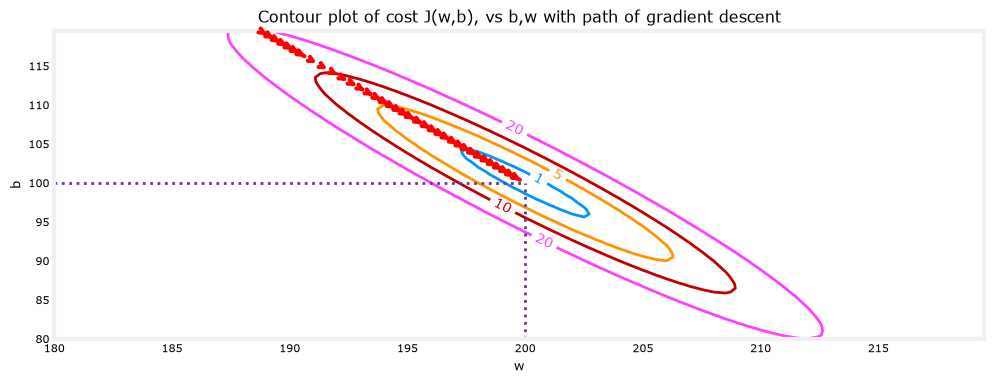

In [14]:

fig, ax = plt.subplots(1,1, figsize=(12,4))
plt_contour_wgrad(x_train, y_train, p_hist, ax, w_range=[180,220,0.5], b_range=[80,120,0.5],
                  contours=[1,5,10,20], resolution=0.5)

In [17]:

# Increased Learning Rate - Overshooting

# Initialize parameters
w_init = 0
b_init = 0

# Set alpha to a large value
iterations = 10
tmp_alpha = 8.0e-1

# Run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha,
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: Cost 3.58e+05  dj_dw: -5.000e+02, dj_db: -8.000e+02  w:  4.000e+02, b: 6.40000e+02
Iteration    1: Cost 1.37e+06  dj_dw:  9.400e+02, dj_db:  1.680e+03  w: -3.520e+02, b:-7.04000e+02
Iteration    2: Cost 5.46e+06  dj_dw: -1.908e+03, dj_db: -3.264e+03  w:  1.174e+03, b: 1.90720e+03
Iteration    3: Cost 2.14e+07  dj_dw:  3.756e+03, dj_db:  6.538e+03  w: -1.830e+03, b:-3.32288e+03
Iteration    4: Cost 8.47e+07  dj_dw: -7.484e+03, dj_db: -1.294e+04  w:  4.157e+03, b: 7.02669e+03
Iteration    5: Cost 3.34e+08  dj_dw:  1.484e+04, dj_db:  2.572e+04  w: -7.715e+03, b:-1.35517e+04
Iteration    6: Cost 1.32e+09  dj_dw: -2.948e+04, dj_db: -5.105e+04  w:  1.587e+04, b: 2.72877e+04
Iteration    7: Cost 5.19e+09  dj_dw:  5.853e+04, dj_db:  1.014e+05  w: -3.095e+04, b:-5.38219e+04
Iteration    8: Cost 2.05e+10  dj_dw: -1.162e+05, dj_db: -2.013e+05  w:  6.203e+04, b: 1.07219e+05
Iteration    9: Cost 8.06e+10  dj_dw:  2.308e+05, dj_db:  3.997e+05  w: -1.226e+05, b:-2.12561e+05


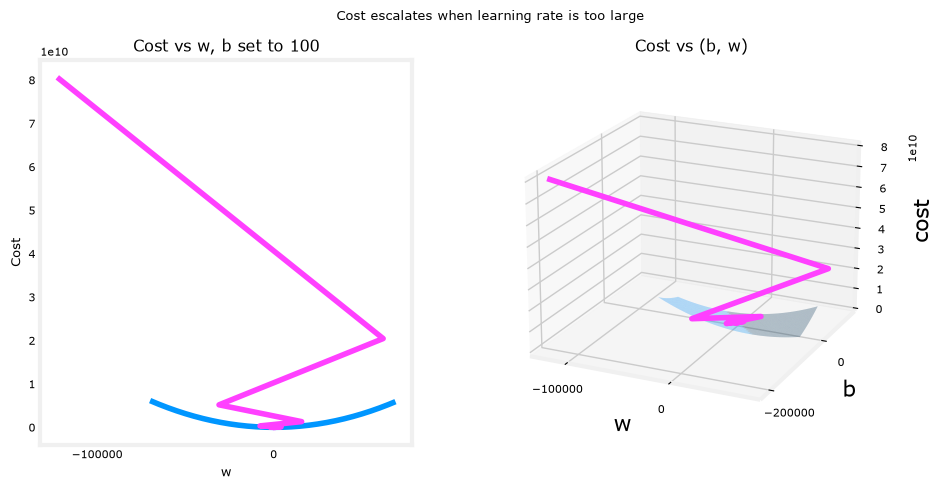

In [18]:
plt_divergence(p_hist, J_hist, x_train, y_train)
plt.show()